# Phase 1 and Phase 1.5 Summary

In Phase 1, a rule-based MIDI Evaluation Pipeline is developed to capture Musical Instrument Digital Interface (MIDI) sequence and compare students’ response against reference. Phase 1.5 extends the functionality so that the pipeline can evaluate not only melody notes (one note at a time) but also block chords (multiple notes played simultaneously).

The personalised, actionable, formative feedback messages are generated across the core dimensions of music (pitch accuracy, timing deviation, and note duration).

The general structure of the designed pipeline:
- Step 0: normalize the start times of the MIDI sequences to make sure the first note starts at t = 0.0, then group simultaneous notes into chords.
- Step 1: edit-distance alignment, to identify missing/extra/wrong pitch in the response sequence.
- Step 2: estimate the overall timing and duration difference between reference and response, using linear regression.
- Step 3: compute metrics to provide event-level feedback (note/chord-level feedback)
- Step 4: compute the summary statistics to provide overview feedback
- Step 5: generate human-readable feedback message from step 3 and step 4
- Step 6: provide an additional overall pass/fail judgement based on step 3 and step 4

##### set up the notebook

In [1]:
referenceMIDI = {
    "performance_type": "reference",
    "notes": [
        {"pitch": 60, "start": 0.00, "duration": 0.40},  # C4 — single note
        {"pitch": 62, "start": 0.50, "duration": 0.40},  # D4 — single note
        {"pitch": 64, "start": 1.00, "duration": 0.40},  # E4 — single note
        # Chord 1: C major (C4, E4, G4) — all three notes start together
        {"pitch": 60, "start": 1.50, "duration": 0.40},
        {"pitch": 64, "start": 1.50, "duration": 0.40},
        {"pitch": 67, "start": 1.50, "duration": 0.40},
        {"pitch": 69, "start": 2.20, "duration": 0.40},  # A4 — single note
        # Chord 2: A minor (A4, C5, E5) — all three notes start together
        {"pitch": 69, "start": 2.80, "duration": 0.40},
        {"pitch": 72, "start": 2.80, "duration": 0.40},
        {"pitch": 76, "start": 2.80, "duration": 0.40},
        {"pitch": 71, "start": 3.50, "duration": 0.40},  # B4 — single note
    ]
}

responseMIDI = {
    "performance_type": "response",
    "notes": [
        {"pitch": 60, "start": 0.00, "duration": 0.48},  # C4  — correct
        {"pitch": 63, "start": 0.60, "duration": 0.48},  # D#4 — wrong pitch (expected D4)
        {"pitch": 64, "start": 1.00, "duration": 0.48},  # E4  — local timing error
        # Chord 1: student plays C major correctly (all 3 notes, within 50ms window)
        {"pitch": 60, "start": 1.80, "duration": 0.48},
        {"pitch": 64, "start": 1.81, "duration": 0.48},  # slight onset jitter, still grouped
        {"pitch": 67, "start": 1.82, "duration": 0.48},
        {"pitch": 69, "start": 2.64, "duration": 0.48},  # A4 — correct
        # Chord 2: student plays A minor imperfectly — missing E5 (76), plays wrong note F5 (77)
        {"pitch": 69, "start": 3.36, "duration": 0.48},
        {"pitch": 72, "start": 3.36, "duration": 0.48},
        {"pitch": 77, "start": 3.37, "duration": 0.48},  # F5 instead of E5
        {"pitch": 71, "start": 4.20, "duration": 0.48},  # B4 — correct but duration error
    ]
}

In [2]:
# Import
from evaluation_function.compare_MIDI import (
    normalize_start_times,
    group_notes_into_events,
    event_alignment_ED,
    estimate_global_timing,
    estimate_global_duration_scale,
    event_level_feedback,
    compute_stats,
    generate_feedback_message,
    compare_performance_ED,
)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

Note: all parameters are defined with a reasonable default value in the code, and all of them can be set by the teachers manually.

### Step 0

**Normalize start times**: Adjust the start time of the first note to t=0 for both the reference and the response MIDI. This action will help eliminate the time gap between student start recording their practice and start playing the first note (if the gap exists).

**Group simultaneous notes into chords**: Notes which start within a 50 ms (default) window are grouped into a block chord event; all others become single-note events.
- Limitation and Possible future work: handle broken chords

A "chord" = multiple(>=3) notes with the same or very close start times
- Block Chords: multiple(>=3) notes with the same start time
- Broken Chords / Arpeggios: multiple(>=3) notes play one after another, in a given order
focus on block chords first. 

#### Result

In [3]:
# Step 0a: Normalise start times
response_notes = normalize_start_times(responseMIDI["notes"])
ref_notes      = normalize_start_times(referenceMIDI["notes"])

print("Normalised response notes:")
for n in response_notes:
    print(" ", n)

print()
print("Normalised reference notes:")
for n in ref_notes:
    print(" ", n)

Normalised response notes:
  {'pitch': 60, 'start': 0.0, 'duration': 0.48}
  {'pitch': 63, 'start': 0.6, 'duration': 0.48}
  {'pitch': 64, 'start': 1.0, 'duration': 0.48}
  {'pitch': 60, 'start': 1.8, 'duration': 0.48}
  {'pitch': 64, 'start': 1.81, 'duration': 0.48}
  {'pitch': 67, 'start': 1.82, 'duration': 0.48}
  {'pitch': 69, 'start': 2.64, 'duration': 0.48}
  {'pitch': 69, 'start': 3.36, 'duration': 0.48}
  {'pitch': 72, 'start': 3.36, 'duration': 0.48}
  {'pitch': 77, 'start': 3.37, 'duration': 0.48}
  {'pitch': 71, 'start': 4.2, 'duration': 0.48}

Normalised reference notes:
  {'pitch': 60, 'start': 0.0, 'duration': 0.4}
  {'pitch': 62, 'start': 0.5, 'duration': 0.4}
  {'pitch': 64, 'start': 1.0, 'duration': 0.4}
  {'pitch': 60, 'start': 1.5, 'duration': 0.4}
  {'pitch': 64, 'start': 1.5, 'duration': 0.4}
  {'pitch': 67, 'start': 1.5, 'duration': 0.4}
  {'pitch': 69, 'start': 2.2, 'duration': 0.4}
  {'pitch': 69, 'start': 2.8, 'duration': 0.4}
  {'pitch': 72, 'start': 2.8, 'dur

In [7]:
# Step 0b: Group into events
# chord_onset_window=0.05 means notes within 50 ms are grouped as a chord.
response_events = group_notes_into_events(response_notes, chord_onset_window=0.05)
ref_events = group_notes_into_events(ref_notes, chord_onset_window=0.05)

print("Response events:")
for i, e in enumerate(response_events):
    print(f"  [{i+1}] event_type={e['event_type']}  event_start={e['event_start']:.2f}  event_duration={e['event_duration']:.2f}  notes={e['notes']}")

print()
print("Reference events:")
for i, e in enumerate(ref_events):
    print(f"  [{i+1}] event_type={e['event_type']}  event_start={e['event_start']:.2f}  event_duration={e['event_duration']:.2f}  notes={e['notes']}")

Response events:
  [1] event_type=note  event_start=0.00  event_duration=0.48  notes=[{'pitch': 60, 'start': 0.0, 'duration': 0.48}]
  [2] event_type=note  event_start=0.60  event_duration=0.48  notes=[{'pitch': 63, 'start': 0.6, 'duration': 0.48}]
  [3] event_type=note  event_start=1.00  event_duration=0.48  notes=[{'pitch': 64, 'start': 1.0, 'duration': 0.48}]
  [4] event_type=chord  event_start=1.80  event_duration=0.48  notes=[{'pitch': 60, 'start': 1.8, 'duration': 0.48}, {'pitch': 64, 'start': 1.81, 'duration': 0.48}, {'pitch': 67, 'start': 1.82, 'duration': 0.48}]
  [5] event_type=note  event_start=2.64  event_duration=0.48  notes=[{'pitch': 69, 'start': 2.64, 'duration': 0.48}]
  [6] event_type=chord  event_start=3.36  event_duration=0.48  notes=[{'pitch': 69, 'start': 3.36, 'duration': 0.48}, {'pitch': 72, 'start': 3.36, 'duration': 0.48}, {'pitch': 77, 'start': 3.37, 'duration': 0.48}]
  [7] event_type=note  event_start=4.20  event_duration=0.48  notes=[{'pitch': 71, 'start':

### Step 1

The main purpose of note alignment here is to identify if there is any missing/extra notes and notes with wrong pitch.

Based on the findings during the project plan phase, Dynamic Time Warping (DTW) is commonly used for alignment. The algorithm can be found in this book (Chpater 3.2 Dynamic Time Warping):
M. Müller, Fundamentals of Music Processing. Cham: Springer International Publishing, 2021, ISBN: 9783030698072. DOI:https://doi.org/10.1007/978-3-030-69808-9.

In general, this DTW algorithm finds an optimal possibly nonlinear alignment between response MIDI sequence to reference MIDI sequence.

Basic approach:
- Evaluating the local cost measure for each pair of elements in the response(X) and reference(Y) sequences. 
- Dynamic programming to find an alignment path between X and Y having minimal overall cost, i.e. DTW distance. The algorithm computes a cumulative distance path, the timestamps of the target MIDI are warped so they perfectly align with the anchor points of the reference MIDI.

However, this basic approach will not correctly handle the missing note case as expected, because it allows a note to match with multiple notes, and each note must be paired. Let's say, there is a note missing in the response, this algorithm tends to match a response note with two reference note, instead of reporting the missing problem.

**Edit-distance alignment**

A simplified version of (Mongeau, M., Sankoff, D. Comparison of musical sequences. Comput Hum 24, 161–175 (1990). https://doi.org/10.1007/BF00117340) is applied.

The Edit-distance approach allows a note to be explicitly left unaligned （i.e. insertions (extra notes) and deletions (missing notes)） at the cost of gap_penalty. The gap penalty is empirically set to 6. This value is chosen to encourage the alignment algorithm to interpret most pitch deviations as replacement (wrong pitches) rather than decomposing them into separate insertion and deletion operations. Such behaviour is more consistent with common music teaching practice, where a note played at the correct temporal position but with an incorrect pitch is typically regarded as a wrong note instead of a missing note accompanied by an extra note.

The reference note sequence and the student's response sequence are aligned using dynamic programming.

The accumulated cost matrix is constructed with cost functions:
- Note vs note: absolute pitch difference in semitones, so that matched note pairs have zero cost while larger pitch deviations have proportionally higher penalties.
- Chord vs chord: Hamming distance on 12-dim pitch-class binary vectors.
    - There is a paper suggesting that considering chord as unordered set of pitch classes: (Rocher, Thomas & Robine, Matthias & Hanna, Pierre & Desainte-Catherine, Myriam. (2010). A Survey Of Chord Distances With Comparison For Chord Analysis). 
- Type mismatch (note vs chord): gap_penalty (forces the aligner to prefer leaving them unmatched).
- Gap (missing/extra event): gap_penalty.

Then, backtracking is performed to recover the optimal alignment path, Each aligned pair or unmatched element is classified into one of the four operation types according to the moving direction during backtracking:
    - diagonal = match (identical pitch)/replacement (wrong pitch)
    - vertical = extra (additional note played)
    - horizontal = missing (note not played)

#### visualisation of the alignment

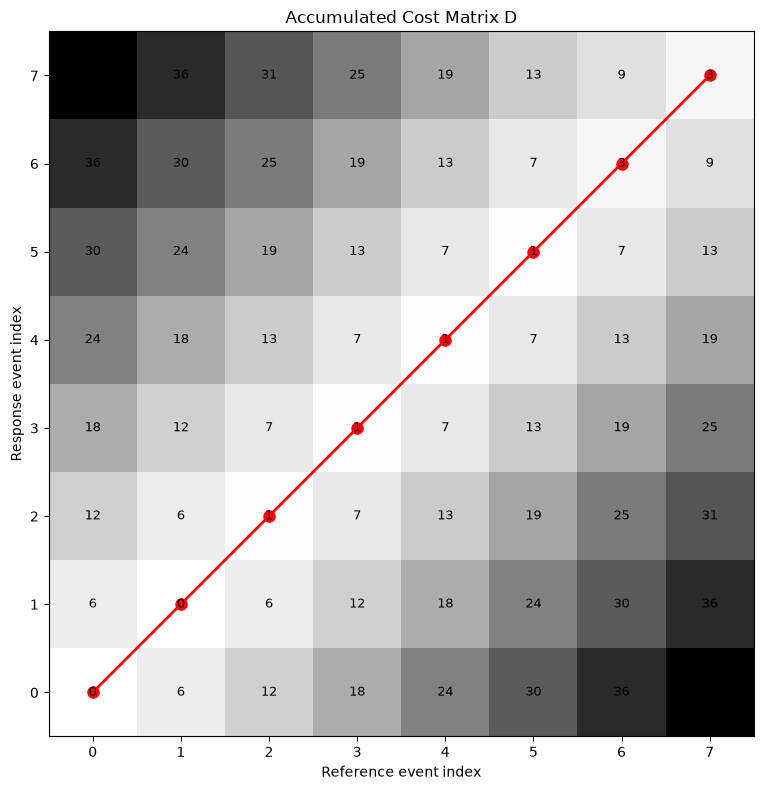

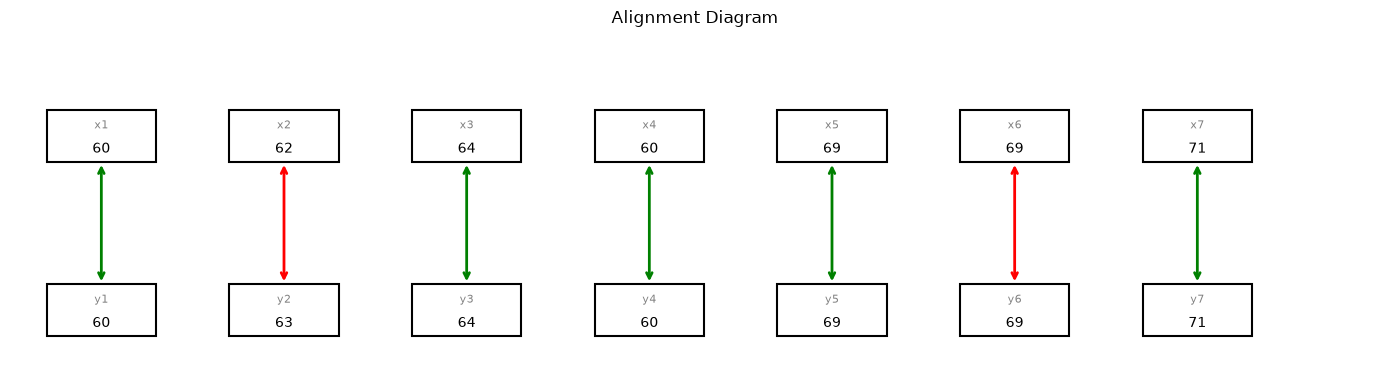

In [ ]:
# Step 1: Align using edit distance
GAP_PENALTY = 6
operations, D = event_alignment_ED(response_events, ref_events, gap_penalty=GAP_PENALTY)
N = len(response_events)
M = len(ref_events)

# Cost matrix
fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(D, origin="lower", cmap="Greys")
for i in range(N + 1):
    for j in range(M + 1):
        ax.text(j, i, str(D[i, j]), ha="center", va="center", fontsize=9)
n = N
m = M
path_rows = [n]
path_cols = [m]
for op in reversed(operations):
    if op["type"] in ("match", "replacement"):
        n = n - 1
        m = m - 1
    elif op["type"] == "extra":
        n = n - 1
    else:
        m = m - 1
    path_rows.append(n)
    path_cols.append(m)
path_rows.reverse()
path_cols.reverse()
ax.plot(path_cols, path_rows, "ro-", markersize=8, linewidth=2)
ax.set_xlabel("Reference event index")
ax.set_ylabel("Response event index")
ax.set_title("Accumulated Cost Matrix D")
plt.tight_layout()
plt.show()

# Alignment diagram
box_w = 1.2
box_h = 0.6
ref_y = 2.5
res_y = 0.5
x_gap = 2.0

ref_x = {}
res_x = {}
x = 0.0
for op in operations:
    if op["type"] == "missing":
        ref_x[op["reference_idx"]] = x
    elif op["type"] == "extra":
        res_x[op["response_idx"]] = x
    else:
        ref_x[op["reference_idx"]] = x
        res_x[op["response_idx"]] = x
    x = x + x_gap

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")
for ref_idx, xpos in ref_x.items():
    pitch = ref_events[ref_idx]["notes"][0]["pitch"]
    ax.add_patch(plt.Rectangle(
        (xpos - box_w / 2, ref_y), box_w, box_h,
        fill=False, edgecolor="black", linewidth=1.5
    ))
    ax.text(xpos, ref_y + box_h * 0.7, "x" + str(ref_idx + 1),
            ha="center", va="center", fontsize=8, color="gray")
    ax.text(xpos, ref_y + box_h * 0.25, str(pitch),
            ha="center", va="center", fontsize=10)
for res_idx, xpos in res_x.items():
    pitch = response_events[res_idx]["notes"][0]["pitch"]
    ax.add_patch(plt.Rectangle(
        (xpos - box_w / 2, res_y), box_w, box_h,
        fill=False, edgecolor="black", linewidth=1.5
    ))
    ax.text(xpos, res_y + box_h * 0.7, "y" + str(res_idx + 1),
            ha="center", va="center", fontsize=8, color="gray")
    ax.text(xpos, res_y + box_h * 0.25, str(pitch),
            ha="center", va="center", fontsize=10)
for op in operations:
    op_type = op["type"]
    if op_type == "missing":
        xpos = ref_x[op["reference_idx"]]
        ax.annotate("", xy=(xpos, res_y + box_h),
                    xytext=(xpos, ref_y),
                    arrowprops=dict(arrowstyle="<->", color="gray",
                                    linestyle="dashed", lw=1.5))
        ax.text(xpos, (ref_y + res_y + box_h) / 2, "missing",
                ha="center", va="center", fontsize=8, color="red")
    elif op_type == "extra":
        xpos = res_x[op["response_idx"]]
        ax.text(xpos, (ref_y + res_y + box_h) / 2, "extra",
                ha="center", va="center", fontsize=8, color="purple")
    elif op_type == "match":
        xpos = ref_x[op["reference_idx"]]
        ax.annotate("", xy=(xpos, res_y + box_h),
                    xytext=(xpos, ref_y),
                    arrowprops=dict(arrowstyle="<->", color="green", lw=2))
    else:
        xpos = ref_x[op["reference_idx"]]
        ax.annotate("", xy=(xpos, res_y + box_h),
                    xytext=(xpos, ref_y),
                    arrowprops=dict(arrowstyle="<->", color="red", lw=2))
ax.set_xlim(-1, x)
ax.set_ylim(0, 4)
ax.set_title("Alignment Diagram")
plt.tight_layout()
plt.show()

### Step 2

It is common for students to play at a slower tempo by setting the metronome to a slower pace during practice. Then after becoming more and more familiar with it, they may speed up unconsciously especially for the easier parts. Therefore, to avoid prompting the tempo problem for every single note in these cases, the global drift problem must be separated from local deviations. 
- `estimate_global_timing` fits a linear regression over all matched note pairs: response_start ≈ scale × ref_start + offset, where scale represents the student's overall tempo relative to the reference (greater than 1.0 indicates playing slower; less than 1.0 indicates playing faster), and offset captures any constant time shift.
- `estimate_global_duration_scale` fits a least-squares regression, this regression line passes through the origin because note duration has no meaningful constant offset term: response_duration ≈ duration_scale × ref_duration, where duration_scale represents the general holding time for notes relative to the reference (greater than 1.0 indicates longer holding; less than 1.0 indicates shorter holding time)
- To ensure the fitting method is statistically and musically meaningful, if the amount of matched pairs available is smaller than three, the functions will assume there is no global tempo trend. 
- The slow/fast decision mainly depends on the scale for timing.

#### Result

In [14]:
# Step 2a: Estimate global timing (tempo drift)
timing_scale, timing_offset = estimate_global_timing(
    operations, response_events, ref_events
)
print(f"timing_scale  = {timing_scale:.4f} ")
print(f"timing_offset = {timing_offset:.4f} seconds")

# Step 2b: Estimate global duration scale
duration_scale = estimate_global_duration_scale(
    operations, response_events, ref_events
)
print(f"duration_scale = {duration_scale:.4f} ")

timing_scale  = 1.2135 
timing_offset = -0.0507 seconds
duration_scale = 1.2000 


### Step 3 - 6

Step 3: Compute metrics for each aligned event pair

While note comparison is relatively trivial, chord comparison can be considered as a set matching problem so that the correctness of a chord can be determined by the overlap between response set and reference set. Additionally, it may require handling partial matches problem (e.g. two out of three chord notes played correctly), consider defining it as imperfect chords. 

- Pitch: exact match for notes, the absolute semitone difference is recorded for feedback; for chords, chord accuracy A = (C − I + |y|) / (2|y|) is computed (chord accuracy metric reference: https://arxiv.org/pdf/2201.05244) and the exact wrong/missing/unexpected pitch is also recorded for feedback.
- Timing and Duration: first removing the global trend, then evaluate the relative difference according to certain proportional threshold value, as a fixed tolerance (e.g. +/-0.5 s) is unfair: it is too tolerant for long notes and overly strict for short notes.
    - Timing: The expected start time is predicted from the global trend line, then the relative difference in start time is calculated by ∣response_start − predicted_start∣ / inter-onset interval (IOI) of the reference note, a note is considered correct if this relative difference is within a threshold. In the feedback, the amount of difference will be reported instead of directly indicate the correctness, so that the students will not be discourage to include their expressiveness in certain parts of the practice. The first note (ref_idx == 0) is always marked as timing-correct, since normalisation in Step 0 guarantees both sequences start at t = 0.
    - Duration: The expected duration is predicted from the global duration scale, then the relative difference in duration is calculated by ∣response_duration − predicted_duration∣ / ref_duration, a note is considered correct if this relative difference is within a threshold.

Step 4:
- Compute the summary statistics to provide overview feedback, including total notes/chords missing, extra, wrong pitch, wrong timing, and wrong duration, as well as boolean flags indicating whether all paired notes are correct on each dimension. The global trend parameters (timing_scale, timing_offset, duration_scale) are also included. 

Step 5: generate human-readable feedback message from step 3 and step 4
- Overview provides a summary of the student's overall performance:
    - Tempo judgement based on timing_scale: explicitly states whether the overall tempo is acceptable, too slow, or too fast, along with the duration_scale as supplementary context
    - Total count of pitch errors, missing notes, and extra notes
- Detail provides actionable, event-level feedback for each issue identified:
    - Missing/extra notes: identifies the specific note and pitch
    - Pitch errors: states the expected and played pitch, and the semitone difference
    - Local timing anomalies: reports the absolute and relative deviation after the global trend has been removed
    - Local duration anomalies: reports the deviation direction and magnitude after the global duration scale has been removed

Step 6: provide an additional overall pass/fail judgement based on step 3 and step 4

## Example feedback message:

In [21]:
# Calling compare_performance_ED() runs all steps in one call.
result = compare_performance_ED(responseMIDI, referenceMIDI)
print(result.feedback_message)


Overview: 
Overall, your tempo is slower than the reference (timing is about 21% behind the reference in general while notes are held about 20% longer than the reference). No worries! You will get better when you practice more to get more familiar with it!
There is 1 note played with the wrong pitch.
There are no missing notes. Great!
There are no extra notes. Good job!
Chords: 1/2 correct, 1/2 imperfect (some notes missing or extra), 0/2 completely wrong.

Note Detail:
Note 2: wrong pitch — expected 62, played 63 (1 semitone(s) off).
Note 3: timing is off by 0.16s (33% of the expected note interval), after accounting for the overall tempo trend.

Chord Detail:
Chord 6 (expected A minor, you played F major): 67% accurate. Missing note(s): E. Extra note(s) played: F.


In [22]:
print("- is_correct:")
print(result.is_correct)
print("- event details:")
print(result.event_details)
print("- stats:")
print(result.stats)

- is_correct:
False
- event details:
[{'event_type': 'note', 'reference_index': 1, 'response_index': 1, 'operation_type': 'match', 'pitch_correct': True, 'pitch_diff': 0, 'timing_correct': True, 'timing_abs_diff': 0.05071899340922707, 'timing_relative_diff': None, 'duration_correct': True, 'duration_abs_diff': 5.551115123125783e-17, 'duration_relative_diff': 1.3877787807814457e-16}, {'event_type': 'note', 'reference_index': 2, 'response_index': 2, 'operation_type': 'replacement', 'pitch_correct': False, 'pitch_diff': 1, 'timing_correct': True, 'timing_abs_diff': 0.04397843019772307, 'timing_relative_diff': 0.08795686039544615, 'duration_correct': True, 'duration_abs_diff': 5.551115123125783e-17, 'duration_relative_diff': 1.3877787807814457e-16}, {'event_type': 'note', 'reference_index': 3, 'response_index': 3, 'operation_type': 'match', 'pitch_correct': True, 'pitch_diff': 0, 'timing_correct': False, 'timing_abs_diff': 0.16276213301378073, 'timing_relative_diff': 0.32552426602756146, '

## Possible future work

visualise the feedback, maybe try the visualisation tool such as LilyPond, music21, or simply use matplotlib to plot PianoRoll.